# AutoMorph on FIVES — vessel-only run, after the tortuosity fix

Identical to `analysis_M2_vessels.ipynb` — the same 32 images, the **same segmentation masks**,
bit-for-bit — but with three changes to how tortuosity is computed:

1. **`detect_vessel_border` returns traced paths.** It previously returned pixels in flood-fill
   *discovery* order. Every tortuosity measure assumes consecutive points are consecutive positions
   along the vessel, so discovery order silently broke all of them: on this data 6.2% of consecutive
   pairs were non-adjacent, averaging 42 px apart and peaking at 145 px on a 912 grid. Arc length was
   inflated severalfold. It is now 0.00%.
2. **Tortuosity only for vessels of at least 50 px.** Arc-chord ratio and curvature are unstable on
   short fragments, where a one-pixel wobble moves the ratio a long way.
3. **Aggregation across vessels stays the mean**, as the original code had it. (A median was tried and
   reverted — it collapsed the between-eye variation; see `docs/tortuosity_fix.md`.)

Both runs here aggregate by mean and binarise at 0.5, so the tracing fix and the length threshold are
the only differences.

Because the segmentation is unchanged, **Dice and the three non-tortuosity features are identical**
to the pre-fix run — a useful control: if `Fractal_dimension`, `Vessel_density` or `Average_width`
moved, something other than tortuosity changed.

Section 4 is the before-and-after comparison. The short version: the fix makes the values
*physiologically correct* and agreement much better, while revealing that correctly-computed
tortuosity barely varies across these 32 eyes — the pre-fix spread was tracing artefact, not anatomy.

> `Average_width` is in nominal microns: FIVES publishes no pixel size, so the benchmark writes a
> placeholder 0.008 mm/pixel. Prediction and truth share the same scaling, so every comparison
> statistic here is unaffected; only the absolute micron value is not physical.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

REPO_ROOT = Path.cwd() if (Path.cwd() / "benchmark").is_dir() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from benchmark.agreement import (
    agreement_table,
    discriminability,
    icc21,
    icc_label,
    informational_strength,
)

FEATURES = [
    "Fractal_dimension",
    "Vessel_density",
    "Average_width",
    "Distance_tortuosity",
    "Squared_curvature_tortuosity",
    "Tortuosity_density",
]

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 9})
pd.set_option("display.width", 200)
print(f"repository root: {REPO_ROOT}")

repository root: /Users/staskh/Sandbox/AutoMorph


## Load and join

In [2]:
RESULTS = REPO_ROOT / "benchmark" / "results" / "M2_vessels_fixed_mean"
PRE_FIX = REPO_ROOT / "benchmark" / "results" / "M2_vessels"
FULL_RESULTS = REPO_ROOT / "benchmark" / "results"
RUN_LABEL = "M0 + M2 vessel only, gate bypassed, tortuosity fix applied"
GATE_ENFORCED = False

scores = pd.read_csv(RESULTS / "vessel_scores.csv")
selection = pd.read_csv(RESULTS / "selection.csv")

paired = pd.read_csv(RESULTS / "features_paired.csv")
predicted = pd.read_csv(RESULTS / "features_predicted.csv")
truth = pd.read_csv(RESULTS / "features_ground_truth.csv")

for frame in (predicted, truth):
    frame[FEATURES] = frame[FEATURES].mask(frame[FEATURES] == -1)

ok = paired[paired["status"] == "ok"]
order = sorted(ok["disease"].unique())
truth_all = truth.rename(columns={f: f"{f}_gt" for f in FEATURES})

full_scores_path = FULL_RESULTS / "vessel_scores.csv"
if full_scores_path.is_file():
    full_scores = pd.read_csv(full_scores_path)
    REJECTED_BY_M1 = set(full_scores.loc[full_scores["status"] != "ok", "key"])
else:
    REJECTED_BY_M1 = set()

# The pre-fix run, for the before-and-after comparison.
PRE_FIX_AVAILABLE = (PRE_FIX / "features_paired.csv").is_file()
if PRE_FIX_AVAILABLE:
    pre_paired = pd.read_csv(PRE_FIX / "features_paired.csv")
    pre_ok = pre_paired[pre_paired["status"] == "ok"]
    pre_truth = pd.read_csv(PRE_FIX / "features_ground_truth.csv")
    pre_truth_all = pre_truth.rename(columns={f: f"{f}_gt" for f in FEATURES})
else:
    print("pre-fix results not found — the comparison section will be skipped")

TORTUOSITY = ["Distance_tortuosity", "Squared_curvature_tortuosity", "Tortuosity_density"]
UNCHANGED = [f for f in FEATURES if f not in TORTUOSITY]

print(f"{len(selection)} selected, {(scores['status'] == 'ok').sum()} segmented, {len(ok)} paired")
print(f"pre-fix results available: {PRE_FIX_AVAILABLE}")

32 selected, 32 segmented, 32 paired
pre-fix results available: True


## 1. Grading the quality gate

The full run drops 6 of 32 images before segmentation and cannot say whether that was right. This
run segments them, so the gate's decisions can be scored against what the segmentation actually
achieved.

Two things to separate:

- **Is the gate discriminating?** Do rejected images really segment worse than accepted ones?
- **Is the trade worth it?** How much Dice does discarding them buy, against how much data it
  costs?

A gate can be statistically discriminating and still be a bad deal.

In [3]:
if not REJECTED_BY_M1:
    print("no full-run scores available — cannot grade the gate")
else:
    graded = ok.assign(
        gate=np.where(ok["key"].isin(REJECTED_BY_M1), "M1 rejected", "M1 accepted")
    )
    display(
        graded.groupby("gate").agg(
            n=("key", "size"),
            dice=("dice", "mean"),
            dice_sd=("dice", "std"),
            sensitivity=("sensitivity", "mean"),
        ).round(4)
    )

    rejected = graded[graded["gate"] == "M1 rejected"]
    accepted = graded[graded["gate"] == "M1 accepted"]
    statistic, p_value = stats.mannwhitneyu(rejected["dice"], accepted["dice"])

    print(f"Mann-Whitney p = {p_value:.3f} — the gate {'IS' if p_value < 0.05 else 'is NOT'} "
          "discriminating between better and worse images")
    print()
    print(f"mean Dice over all {len(ok)}:            {ok['dice'].mean():.4f}")
    print(f"mean Dice over the {len(accepted)} accepted:      {accepted['dice'].mean():.4f}")
    print(f"  -> discarding {len(rejected)} images ({100 * len(rejected) / len(ok):.0f}% of the cohort) "
          f"buys {accepted['dice'].mean() - ok['dice'].mean():+.4f} Dice")

,n,dice,dice_sd,sensitivity
gate,,,,
M1 accepted,26,0.8321,0.0534,0.7474
M1 rejected,6,0.7936,0.0443,0.6867


Mann-Whitney p = 0.025 — the gate IS discriminating between better and worse images

mean Dice over all 32:            0.8249
mean Dice over the 26 accepted:      0.8321
  -> discarding 6 images (19% of the cohort) buys +0.0072 Dice


In [4]:
if REJECTED_BY_M1:
    print("The rejected images, worst first — compare against the accepted median:")
    display(
        rejected[["key", "disease", "dice", "sensitivity"]]
        .sort_values("dice")
        .round(4)
        .reset_index(drop=True)
    )
    median_accepted = accepted["dice"].median()
    as_good = (rejected["dice"] >= median_accepted).sum()
    print(f"accepted median Dice = {median_accepted:.4f}")
    print(f"{as_good} of {len(rejected)} rejected images score at or above it — "
          "removed despite segmenting as well as a typical accepted image")

The rejected images, worst first — compare against the accepted median:


,key,disease,dice,sensitivity
0,test_167_N,normal,0.7172,0.5807
1,test_56_D,dr,0.7643,0.6236
2,test_158_N,normal,0.8106,0.7242
3,test_151_N,normal,0.8120,0.7114
4,test_162_N,normal,0.8255,0.7469
5,test_161_N,normal,0.8322,0.7333


accepted median Dice = 0.8447
0 of 6 rejected images score at or above it — removed despite segmenting as well as a typical accepted image


/var/folders/fr/9n81007x72d8q41sk2r0hsfm0000gn/T/ipykernel_92062/3568842782.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([graded.loc[graded["gate"] == g, "dice"] for g in groups], labels=groups,


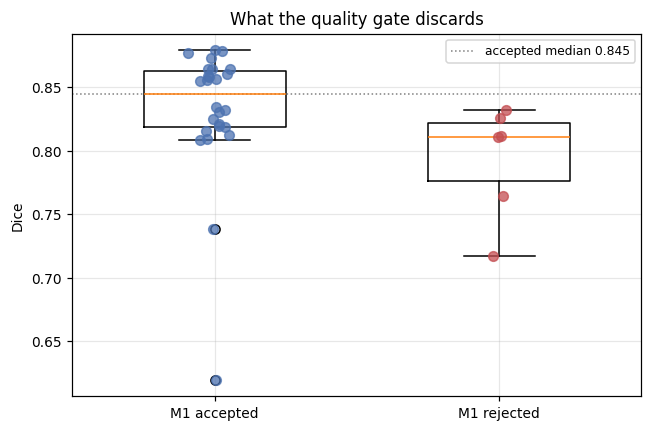

In [5]:
if REJECTED_BY_M1:
    fig, ax = plt.subplots(figsize=(6, 4))
    groups = ["M1 accepted", "M1 rejected"]
    ax.boxplot([graded.loc[graded["gate"] == g, "dice"] for g in groups], labels=groups,
               widths=0.5)
    for index, group in enumerate(groups, start=1):
        values = graded.loc[graded["gate"] == group, "dice"]
        ax.scatter(np.random.default_rng(0).normal(index, 0.04, len(values)), values,
                   alpha=0.75, s=40, zorder=3,
                   color="#4C72B0" if group == "M1 accepted" else "#C44E52")
    ax.axhline(accepted["dice"].median(), color="grey", ls=":", lw=1,
               label=f"accepted median {accepted['dice'].median():.3f}")
    ax.set(ylabel="Dice", title="What the quality gate discards")
    ax.legend(fontsize=8)
    fig.tight_layout()

## 2. Segmentation accuracy

Vessels occupy roughly 2% of the field of view, so **specificity and accuracy sit near 1 for any
prediction** and carry almost no information. Read Dice and IoU; read sensitivity to see which way
the errors fall.

In [6]:
metrics = ["dice", "iou", "sensitivity", "specificity"]

display(ok[metrics].describe().round(4))
display(ok.groupby("disease")[metrics].agg(["mean", "std"]).round(4))

,dice,iou,sensitivity,specificity
count,32.0000,32.0000,32.0000,32.0000
mean,0.8249,0.7050,0.7360,0.9948
std,0.0533,0.0712,0.0799,0.0022
min,0.6196,0.4489,0.4636,0.9909
25%,0.8122,0.6838,0.7123,0.9928
50%,0.8313,0.7113,0.7389,0.9948
75%,0.8591,0.7530,0.7957,0.9965
max,0.8792,0.7845,0.8281,0.9990


dice             iou         sensitivity         specificity        
            mean     std    mean     std        mean     std        mean     std
disease                                                                         
amd       0.8530  0.0255  0.7445  0.0382      0.7761  0.0483      0.9948  0.0016
dr        0.7856  0.0782  0.6525  0.0995      0.6738  0.1088      0.9965  0.0024
glaucoma  0.8420  0.0234  0.7277  0.0350      0.7628  0.0419      0.9941  0.0021
normal    0.8188  0.0473  0.6955  0.0653      0.7312  0.0723      0.9936  0.0017

/var/folders/fr/9n81007x72d8q41sk2r0hsfm0000gn/T/ipykernel_92062/3177343376.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([ok.loc[ok["disease"] == d, "dice"] for d in order], labels=order)


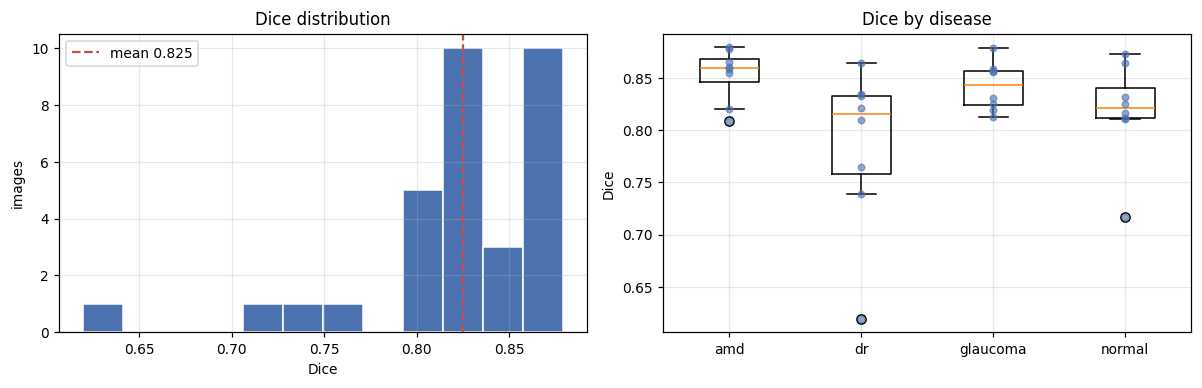

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].hist(ok["dice"], bins=12, color="#4C72B0", edgecolor="white")
axes[0].axvline(ok["dice"].mean(), color="#C44E52", ls="--", label=f"mean {ok['dice'].mean():.3f}")
axes[0].set(xlabel="Dice", ylabel="images", title="Dice distribution")
axes[0].legend()

axes[1].boxplot([ok.loc[ok["disease"] == d, "dice"] for d in order], labels=order)
for index, disease in enumerate(order, start=1):
    values = ok.loc[ok["disease"] == disease, "dice"]
    axes[1].scatter(np.full(len(values), index), values, alpha=0.6, s=18, color="#4C72B0", zorder=3)
axes[1].set(ylabel="Dice", title="Dice by disease")

fig.tight_layout()

correlation of Dice with sensitivity: 0.987
correlation of Dice with specificity: -0.553


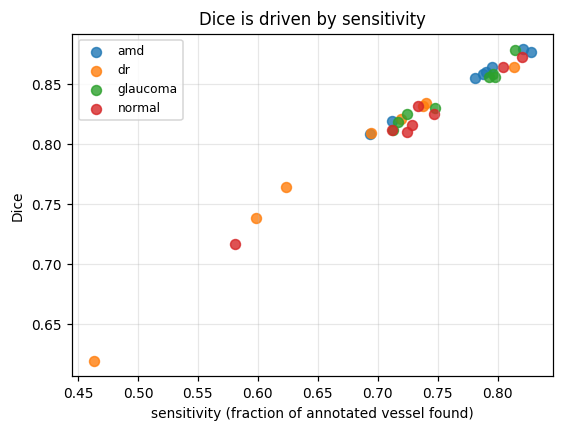

In [8]:
fig, ax = plt.subplots(figsize=(5.2, 4))
for disease in order:
    subset = ok[ok["disease"] == disease]
    ax.scatter(subset["sensitivity"], subset["dice"], label=disease, s=42, alpha=0.8)
ax.set(xlabel="sensitivity (fraction of annotated vessel found)", ylabel="Dice",
       title="Dice is driven by sensitivity")
ax.legend(fontsize=8)
fig.tight_layout()

print("correlation of Dice with sensitivity:", round(ok["dice"].corr(ok["sensitivity"]), 3))
print("correlation of Dice with specificity:", round(ok["dice"].corr(ok["specificity"]), 3))

## 3. Feature agreement

For each feature, predicted against ground truth. Definitions live in `benchmark/agreement.py`,
which is unit-tested — ICC in particular against hand-computed ANOVA values.

- **bias** / **rel_bias_%** — mean signed difference, absolute and as a percentage of the truth's
  mean. A systematic offset, correctable by calibration if it is stable.
- **MAE** / **MAPE_%** — mean absolute error, in the feature's own units and as a percentage.
- **Pearson r** — linear association. Deliberately blind to bias: a constant offset still scores
  1.0. **Spearman** — rank association, which is what matters if the feature orders patients.
- **ICC(2,1)** — intraclass correlation, two-way random effects, absolute agreement, single
  measurement. Unlike Pearson it *charges for systematic bias*, so it is the honest headline
  number. Bands: <0.5 poor, 0.5–0.75 moderate, 0.75–0.9 good, >0.9 excellent. Bootstrap 95%
  intervals are shown because n is small.
- **Bland–Altman limits** — mean difference ± 1.96 SD.

The gap between Pearson and ICC is the interesting column: where Pearson is high and ICC much
lower, the prediction tracks the truth but is offset from it.

In [9]:
agreement = agreement_table(ok, FEATURES, interval=True)

display(
    agreement[
        ["n", "gt_mean", "pred_mean", "bias", "rel_bias_%", "MAE", "MAPE_%",
         "pearson_r", "spearman_r", "ICC21", "ICC_lo", "ICC_hi", "ICC_reading"]
    ].round(3)
)

,n,gt_mean,pred_mean,bias,rel_bias_%,MAE,MAPE_%,pearson_r,spearman_r,ICC21,ICC_lo,ICC_hi,ICC_reading
feature,,,,,,,,,,,,,
Fractal_dimension,32,1.473,1.443,-0.030,-2.007,0.030,2.024,0.926,0.869,0.701,0.494,0.810,moderate
Vessel_density,32,0.084,0.066,-0.018,-21.421,0.018,22.052,0.889,0.792,0.409,0.183,0.574,poor
Average_width,32,115.367,100.435,-14.932,-12.943,14.932,12.886,0.766,0.832,0.319,0.212,0.405,poor
Distance_tortuosity,32,1.093,1.088,-0.005,-0.473,0.007,0.631,0.693,0.849,0.618,0.335,0.911,moderate
Squared_curvature_tortuosity,32,0.132,0.126,-0.006,-4.670,0.016,11.943,0.252,0.250,0.236,-0.098,0.530,poor
Tortuosity_density,32,0.625,0.613,-0.013,-2.019,0.031,4.856,0.827,0.720,0.813,0.561,0.911,good


In [10]:
# Where does ICC disagree with Pearson? That gap is exactly the systematic bias.
gap = pd.DataFrame(
    {
        "pearson_r": agreement["pearson_r"],
        "ICC21": agreement["ICC21"],
        "pearson_minus_ICC": agreement["pearson_r"] - agreement["ICC21"],
        "rel_bias_%": agreement["rel_bias_%"],
    }
).sort_values("pearson_minus_ICC", ascending=False)

display(gap.round(3))
print("A large gap means the prediction tracks the truth but sits offset from it.")

,pearson_r,ICC21,pearson_minus_ICC,rel_bias_%
feature,,,,
Vessel_density,0.889,0.409,0.480,-21.421
Average_width,0.766,0.319,0.446,-12.943
Fractal_dimension,0.926,0.701,0.225,-2.007
Distance_tortuosity,0.693,0.618,0.074,-0.473
Squared_curvature_tortuosity,0.252,0.236,0.015,-4.670
Tortuosity_density,0.827,0.813,0.015,-2.019


A large gap means the prediction tracks the truth but sits offset from it.


In [11]:
# Is the linear agreement statistically distinguishable from zero at this sample size?
for feature in FEATURES:
    pair = ok[[f"{feature}_pred", f"{feature}_gt"]].dropna()
    r, p = stats.pearsonr(pair[f"{feature}_pred"], pair[f"{feature}_gt"])
    rho, p_rho = stats.spearmanr(pair[f"{feature}_pred"], pair[f"{feature}_gt"])
    verdict = "" if p < 0.05 else "   <-- not significant"
    print(f"{feature:32s} n={len(pair):3d}  r={r:6.3f} (p={p:.2g})   rho={rho:6.3f} (p={p_rho:.2g}){verdict}")

Fractal_dimension                n= 32  r= 0.926 (p=3.2e-14)   rho= 0.869 (p=1.1e-10)
Vessel_density                   n= 32  r= 0.889 (p=1.1e-11)   rho= 0.792 (p=6.7e-08)
Average_width                    n= 32  r= 0.766 (p=3.3e-07)   rho= 0.832 (p=3.5e-09)
Distance_tortuosity              n= 32  r= 0.693 (p=1.1e-05)   rho= 0.849 (p=8.2e-10)
Squared_curvature_tortuosity     n= 32  r= 0.252 (p=0.16)   rho= 0.250 (p=0.17)   <-- not significant
Tortuosity_density               n= 32  r= 0.827 (p=5.2e-09)   rho= 0.720 (p=3.5e-06)


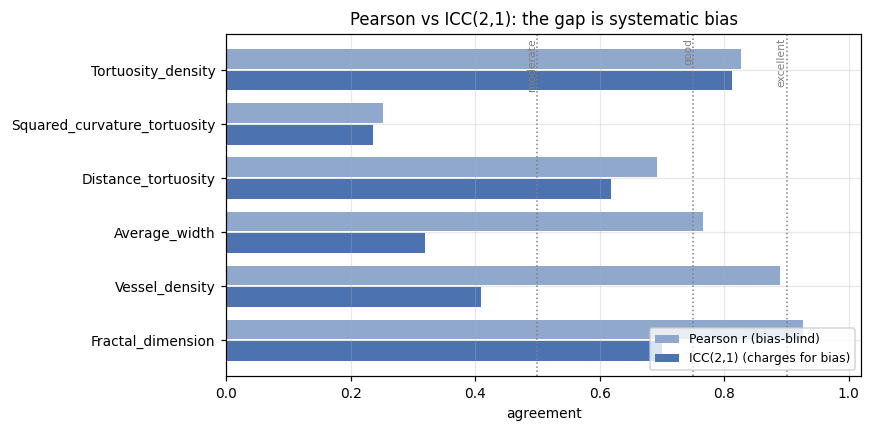

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
position = np.arange(len(FEATURES))

ax.barh(position + 0.2, agreement.loc[FEATURES, "pearson_r"], height=0.36,
        label="Pearson r (bias-blind)", color="#8FA8CC")
ax.barh(position - 0.2, agreement.loc[FEATURES, "ICC21"], height=0.36,
        label="ICC(2,1) (charges for bias)", color="#4C72B0")

for threshold, name in ((0.9, "excellent"), (0.75, "good"), (0.5, "moderate")):
    ax.axvline(threshold, color="grey", ls=":", lw=1)
    ax.text(threshold, len(FEATURES) - 0.4, name, fontsize=7, rotation=90,
            va="top", ha="right", color="grey")

ax.set(yticks=position, yticklabels=FEATURES, xlabel="agreement", xlim=(0, 1.02),
       title="Pearson vs ICC(2,1): the gap is systematic bias")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()

### Does any single image carry the result?

At this sample size one extreme value can manufacture a correlation. Leave-one-out on the ICC finds
it: if dropping a single image moves ICC by more than about 0.15, the agreement is that image's
doing, not the model's.

This is not hypothetical — in the vessel-only run `Squared_curvature_tortuosity` scores ICC 0.544
until one 13x outlier is removed, whereupon it collapses to 0.144. Spearman, being rank-based, is
immune to leverage and stays low throughout, which is why both are reported.

In [13]:
rows = []
for feature in FEATURES:
    pair = ok[["key", f"{feature}_pred", f"{feature}_gt"]].dropna()
    predicted = pair[f"{feature}_pred"].to_numpy()
    reference = pair[f"{feature}_gt"].to_numpy()
    full = icc21(predicted, reference)

    worst_key, worst_icc = None, full
    for position in range(len(pair)):
        keep = np.arange(len(pair)) != position
        without = icc21(predicted[keep], reference[keep])
        if abs(without - full) > abs(worst_icc - full):
            worst_key, worst_icc = pair["key"].iloc[position], without

    rows.append(
        {
            "feature": feature,
            "ICC_all": full,
            "most_influential_image": worst_key,
            "ICC_without_it": worst_icc,
            "swing": worst_icc - full,
            "fragile": abs(worst_icc - full) > 0.15,
        }
    )

leverage = pd.DataFrame(rows).set_index("feature")
display(leverage.round(3))

fragile = leverage[leverage["fragile"]]
if len(fragile):
    print("Leverage-dependent — do not read the ICC point estimate alone:")
    for feature, row in fragile.iterrows():
        print(f"  {feature}: {row['ICC_all']:.3f} -> {row['ICC_without_it']:.3f} "
              f"without {row['most_influential_image']}")
else:
    print("No single image moves any ICC by more than 0.15.")

,ICC_all,most_influential_image,ICC_without_it,swing,fragile
feature,,,,,
Fractal_dimension,0.701,test_52_D,0.612,-0.089,False
Vessel_density,0.409,test_52_D,0.301,-0.108,False
Average_width,0.319,test_16_A,0.296,-0.023,False
Distance_tortuosity,0.618,test_167_N,0.818,0.200,True
Squared_curvature_tortuosity,0.236,test_16_A,0.327,0.091,False
Tortuosity_density,0.813,test_67_D,0.764,-0.049,False


Leverage-dependent — do not read the ICC point estimate alone:
  Distance_tortuosity: 0.618 -> 0.818 without test_167_N


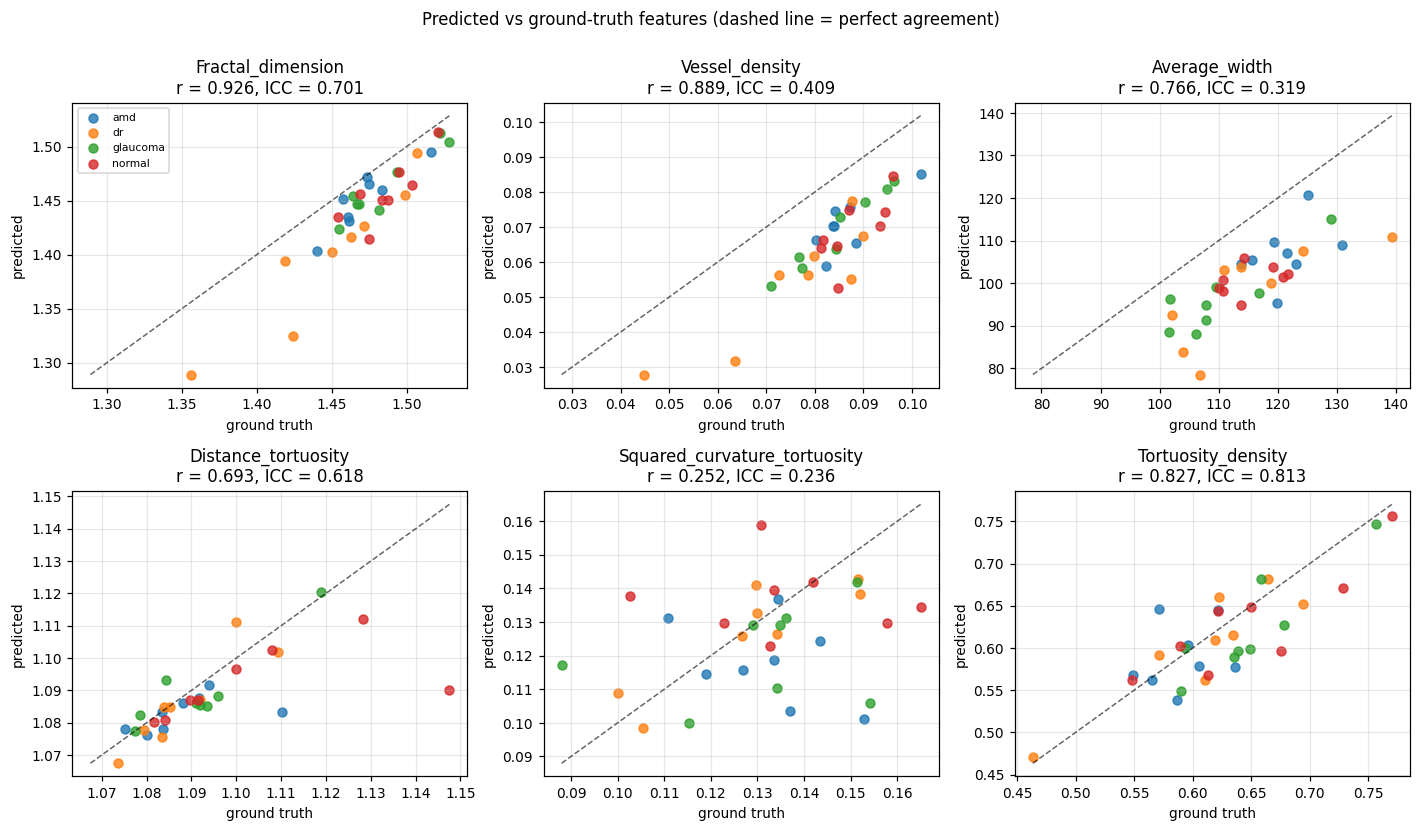

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))

for ax, feature in zip(axes.ravel(), FEATURES):
    pair = ok[[f"{feature}_pred", f"{feature}_gt", "disease"]].dropna()
    for disease in order:
        subset = pair[pair["disease"] == disease]
        ax.scatter(subset[f"{feature}_gt"], subset[f"{feature}_pred"], label=disease, s=34, alpha=0.8)

    combined_values = pd.concat([pair[f"{feature}_gt"], pair[f"{feature}_pred"]])
    limits = [combined_values.min(), combined_values.max()]
    ax.plot(limits, limits, "k--", lw=1, alpha=0.6)
    r = pair[f"{feature}_pred"].corr(pair[f"{feature}_gt"])
    ax.set(xlabel="ground truth", ylabel="predicted",
           title=f"{feature}\nr = {r:.3f}, ICC = {agreement.loc[feature, 'ICC21']:.3f}")

axes[0, 0].legend(fontsize=7)
fig.suptitle("Predicted vs ground-truth features (dashed line = perfect agreement)", y=1.0)
fig.tight_layout()

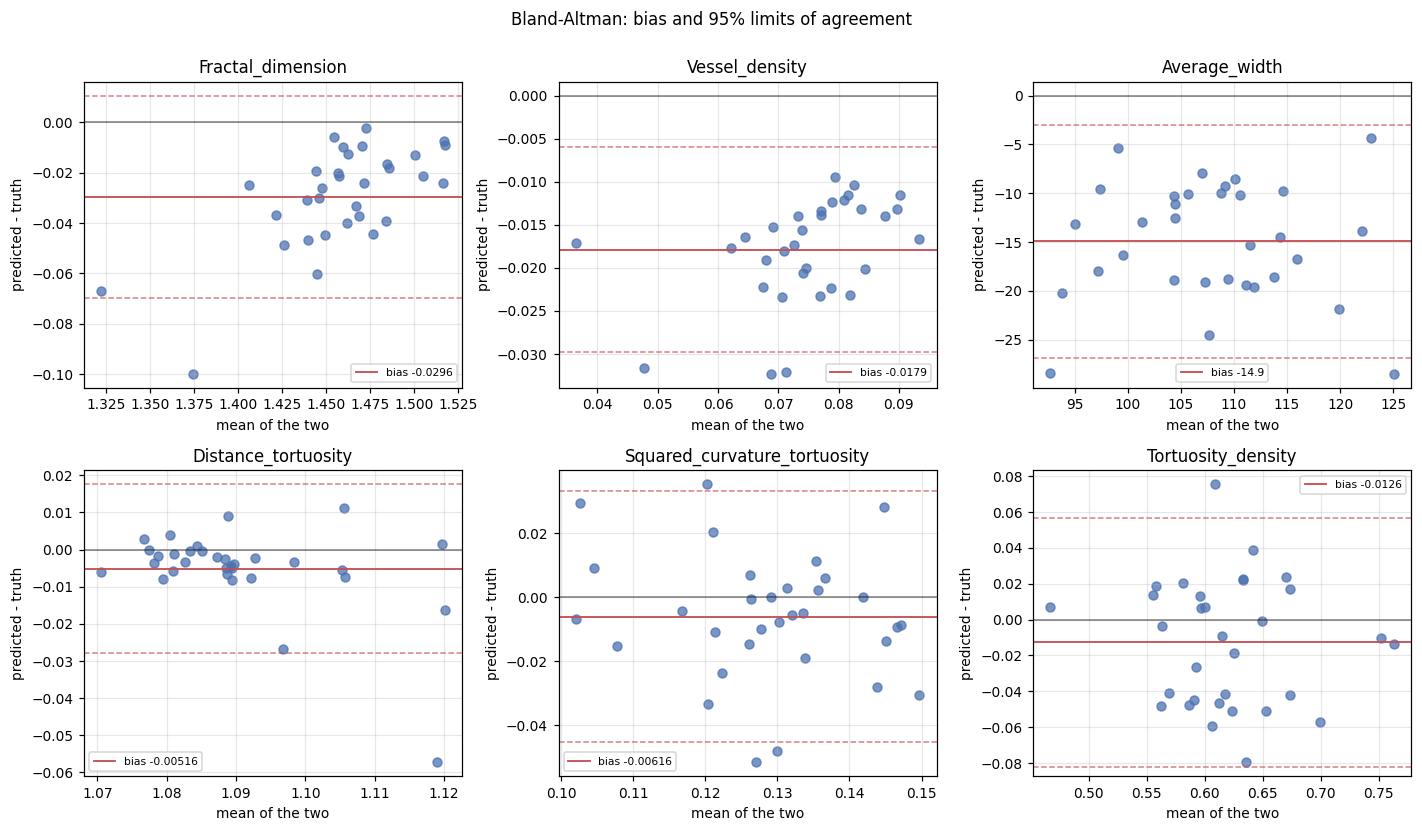

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))

for ax, feature in zip(axes.ravel(), FEATURES):
    pair = ok[[f"{feature}_pred", f"{feature}_gt"]].dropna()
    mean = (pair[f"{feature}_pred"] + pair[f"{feature}_gt"]) / 2
    difference = pair[f"{feature}_pred"] - pair[f"{feature}_gt"]

    ax.scatter(mean, difference, s=34, alpha=0.75, color="#4C72B0")
    ax.axhline(0, color="k", lw=1, alpha=0.5)
    ax.axhline(difference.mean(), color="#C44E52", lw=1.2, label=f"bias {difference.mean():.3g}")
    for limit in (difference.mean() - 1.96 * difference.std(), difference.mean() + 1.96 * difference.std()):
        ax.axhline(limit, color="#C44E52", ls="--", lw=1, alpha=0.7)
    ax.set(xlabel="mean of the two", ylabel="predicted - truth", title=feature)
    ax.legend(fontsize=7)

fig.suptitle("Bland-Altman: bias and 95% limits of agreement", y=1.0)
fig.tight_layout()

## 4. Before and after the tortuosity fix

The segmentation is byte-identical between the two runs, so anything that moved here is the feature
formula and nothing else.

**The control first.** `Fractal_dimension`, `Vessel_density` and `Average_width` do not depend on
vessel tracing, so they must be unchanged. If they are not, something beyond tortuosity moved.

In [16]:
if PRE_FIX_AVAILABLE:
    control = []
    for feature in UNCHANGED:
        after = ok.set_index("key")[f"{feature}_pred"]
        before = pre_ok.set_index("key")[f"{feature}_pred"].reindex(after.index)
        control.append({"feature": feature, "max_abs_change": (after - before).abs().max()})
    control = pd.DataFrame(control).set_index("feature")
    display(control)
    print("control holds — the non-tortuosity features are untouched"
          if control["max_abs_change"].max() == 0 else
          "WARNING: a non-tortuosity feature moved; the change is not confined to tortuosity")

,max_abs_change
feature,
Fractal_dimension,0.0
Vessel_density,0.0
Average_width,0.0


control holds — the non-tortuosity features are untouched


### Agreement: does the prediction now match the truth better?

In [17]:
if PRE_FIX_AVAILABLE:
    before_agreement = agreement_table(pre_ok, FEATURES)
    delta = pd.DataFrame(
        {
            "ICC_before": before_agreement["ICC21"],
            "ICC_after": agreement["ICC21"],
            "ICC_change": agreement["ICC21"] - before_agreement["ICC21"],
            "MAPE%_before": before_agreement["MAPE_%"],
            "MAPE%_after": agreement["MAPE_%"],
            "bias%_before": before_agreement["rel_bias_%"],
            "bias%_after": agreement["rel_bias_%"],
        }
    )
    display(delta.round(3))

,ICC_before,ICC_after,ICC_change,MAPE%_before,MAPE%_after,bias%_before,bias%_after
feature,,,,,,,
Fractal_dimension,0.701,0.701,0.000,2.024,2.024,-2.007,-2.007
Vessel_density,0.409,0.409,0.000,22.052,22.052,-21.421,-21.421
Average_width,0.319,0.319,0.000,12.886,12.886,-12.943,-12.943
Distance_tortuosity,0.412,0.618,0.206,27.647,0.631,10.643,-0.473
Squared_curvature_tortuosity,0.544,0.236,-0.308,90.155,11.943,10.163,-4.670
Tortuosity_density,0.757,0.813,0.056,3.552,4.856,-0.574,-2.019


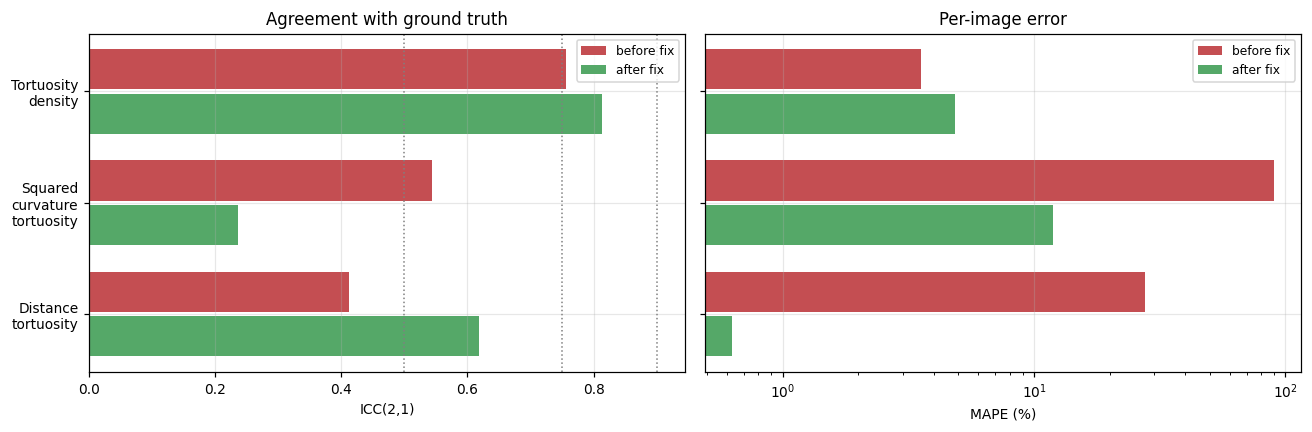

In [18]:
if PRE_FIX_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    position = np.arange(len(TORTUOSITY))

    axes[0].barh(position + 0.2, before_agreement.loc[TORTUOSITY, "ICC21"], height=0.36,
                 label="before fix", color="#C44E52")
    axes[0].barh(position - 0.2, agreement.loc[TORTUOSITY, "ICC21"], height=0.36,
                 label="after fix", color="#55A868")
    for threshold in (0.5, 0.75, 0.9):
        axes[0].axvline(threshold, color="grey", ls=":", lw=1)
    axes[0].set(yticks=position, yticklabels=[t.replace("_", "\n") for t in TORTUOSITY],
                xlabel="ICC(2,1)", title="Agreement with ground truth")
    axes[0].legend(fontsize=8)

    axes[1].barh(position + 0.2, before_agreement.loc[TORTUOSITY, "MAPE_%"], height=0.36,
                 label="before fix", color="#C44E52")
    axes[1].barh(position - 0.2, agreement.loc[TORTUOSITY, "MAPE_%"], height=0.36,
                 label="after fix", color="#55A868")
    axes[1].set(yticks=position, yticklabels=["" for _ in TORTUOSITY],
                xlabel="MAPE (%)", title="Per-image error", xscale="log")
    axes[1].legend(fontsize=8)

    fig.tight_layout()

### Are the values themselves plausible now?

A distance tortuosity is an arc-to-chord ratio: 1.0 is a straight vessel, and retinal vessels sit
just above it. A value of 3.4 would mean the vessel wanders more than three times its end-to-end
distance, which does not happen — it was the inflated arc length.

In [19]:
if PRE_FIX_AVAILABLE:
    rows = []
    for feature in TORTUOSITY:
        for label, frame in (("before", pre_truth), ("after", truth)):
            values = frame[feature].dropna()
            spread = values.quantile(0.75) - values.quantile(0.25)
            rows.append(
                {
                    "feature": feature,
                    "fix": label,
                    "gt_median": values.median(),
                    "gt_min": values.min(),
                    "gt_max": values.max(),
                    "IQR/median": spread / values.median() if values.median() else np.nan,
                }
            )
    display(pd.DataFrame(rows).set_index(["feature", "fix"]).round(4))

gt_median  gt_min    gt_max  IQR/median
feature                      fix                                            
Distance_tortuosity          before     3.3799  2.0313    5.9654      0.3734
                             after      1.0904  1.0736    1.1475      0.0123
Squared_curvature_tortuosity before    19.8782  8.6438  267.8028      0.7379
                             after      0.1335  0.0880    0.1650      0.1234
Tortuosity_density           before     0.6891  0.6127    0.7743      0.1014
                             after      0.6217  0.4635    0.7701      0.0999

### The catch: the spread was largely artefact

Agreement improved sharply — but the *between-eye spread* collapsed. Correctly computed, these
measures are nearly the same for every eye in this cohort.

That means the pre-fix "informational strength" was not anatomy. The apparent variation came from
per-image differences in how badly the tracing jumped, which is noise dressed as signal. A feature
cannot discriminate between eyes if it takes the same value for all of them, however precisely it
is measured — so `spread_to_noise` is the number to watch here, not ICC.

The 50-px threshold is not responsible: with ordering fixed, ground-truth `Distance_tortuosity`
spread is 0.0024 at a 15-px threshold and 0.0039 at 50 px. The collapse is the ordering fix.

In [20]:
if PRE_FIX_AVAILABLE:
    before_combined = discriminability(before_agreement, informational_strength(pre_ok, FEATURES))
    after_combined = discriminability(agreement, informational_strength(ok, FEATURES))
    display(
        pd.DataFrame(
            {
                "IQR/med_before": before_combined["gt_IQR_over_median"],
                "IQR/med_after": after_combined["gt_IQR_over_median"],
                "spread/noise_before": before_combined["spread_to_noise"],
                "spread/noise_after": after_combined["spread_to_noise"],
            }
        ).round(4)
    )
    print("Below 1.0, measurement noise covers the whole interquartile range.")

,IQR/med_before,IQR/med_after,spread/noise_before,spread/noise_after
feature,,,,
Fractal_dimension,0.0228,0.0228,1.6454,1.6454
Vessel_density,0.1041,0.1041,1.4458,1.4458
Average_width,0.1051,0.1051,1.9662,1.9662
Distance_tortuosity,0.3734,0.0123,0.9625,1.1530
Squared_curvature_tortuosity,0.7379,0.1234,0.4138,0.8244
Tortuosity_density,0.1014,0.0999,2.3738,1.7557


Below 1.0, measurement noise covers the whole interquartile range.


## 4. Does Dice predict feature error?

If it does, Dice is a usable proxy for feature trustworthiness on unlabelled data — the only
situation that matters in practice, since you will not have annotations. If it does not, a good Dice
is no guarantee that the reported morphometry is right.

In [21]:
rows = []
for feature in FEATURES:
    pair = ok[[f"{feature}_pred", f"{feature}_gt", "dice", "sensitivity"]].dropna()
    relative_error = (pair[f"{feature}_pred"] - pair[f"{feature}_gt"]).abs() / pair[f"{feature}_gt"].abs()
    rows.append(
        {
            "feature": feature,
            "corr(dice, |rel err|)": pair["dice"].corr(relative_error),
            "corr(sens, |rel err|)": pair["sensitivity"].corr(relative_error),
            "median_|rel err|_%": 100 * relative_error.median(),
        }
    )

proxy_table = pd.DataFrame(rows).set_index("feature")
display(proxy_table.round(3))

,"corr(dice, |rel err|)","corr(sens, |rel err|)",median_|rel err|_%
feature,,,
Fractal_dimension,-0.927,-0.930,1.691
Vessel_density,-0.957,-0.990,21.333
Average_width,-0.712,-0.739,12.416
Distance_tortuosity,-0.406,-0.393,0.388
Squared_curvature_tortuosity,0.075,0.070,8.715
Tortuosity_density,0.005,-0.023,3.655


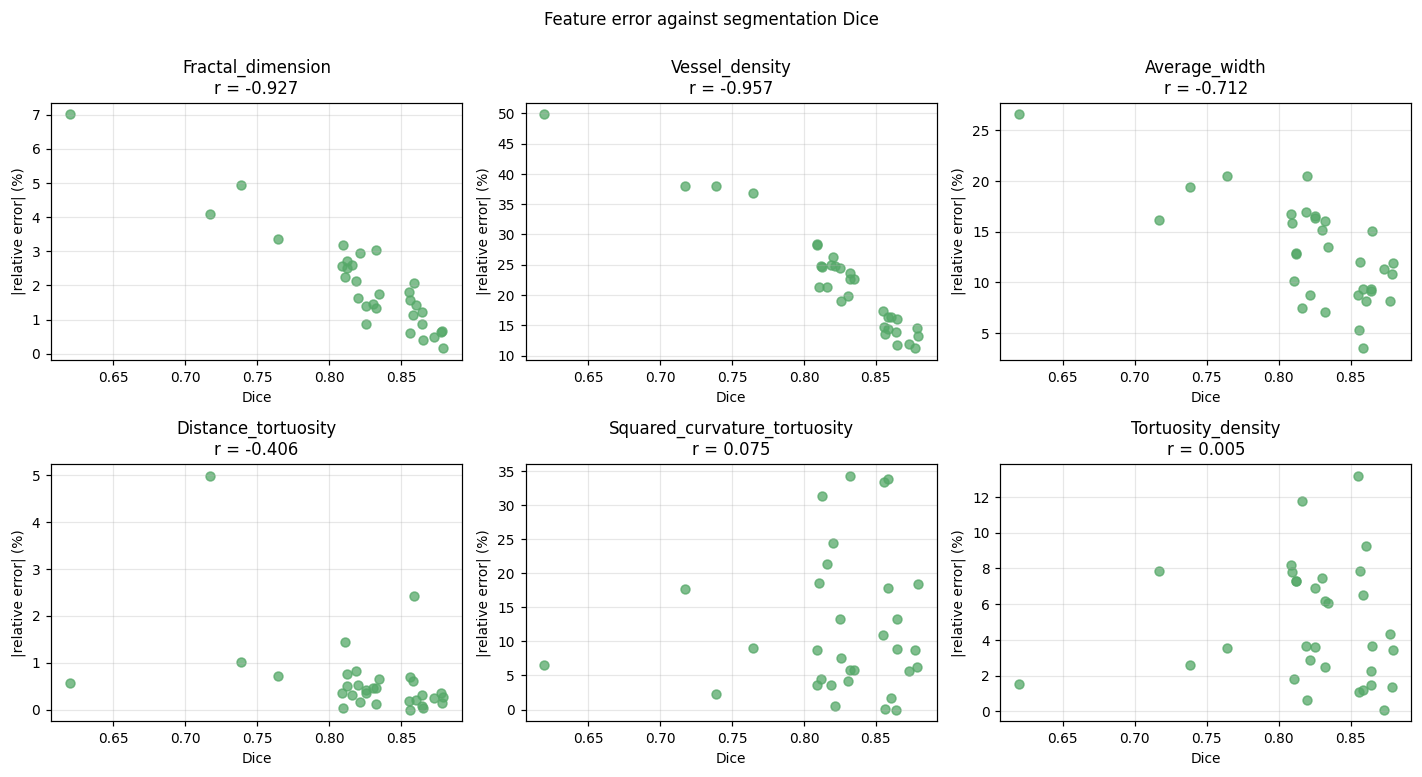

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for ax, feature in zip(axes.ravel(), FEATURES):
    pair = ok[[f"{feature}_pred", f"{feature}_gt", "dice"]].dropna()
    relative_error = 100 * (pair[f"{feature}_pred"] - pair[f"{feature}_gt"]).abs() / pair[f"{feature}_gt"].abs()
    ax.scatter(pair["dice"], relative_error, s=34, alpha=0.75, color="#55A868")
    ax.set(xlabel="Dice", ylabel="|relative error| (%)",
           title=f"{feature}\nr = {pair['dice'].corr(relative_error):.3f}")

fig.suptitle("Feature error against segmentation Dice", y=1.0)
fig.tight_layout()

## 5. Per-disease agreement

Small groups — read as indicative, not conclusive.

In [23]:
for disease in order:
    subset = ok[ok["disease"] == disease]
    print(f"\n=== {disease}  (n={len(subset)}, mean Dice {subset['dice'].mean():.3f}) ===")
    display(
        agreement_table(subset, FEATURES)[
            ["rel_bias_%", "MAE", "MAPE_%", "pearson_r", "spearman_r", "ICC21"]
        ].round(3)
    )


=== amd  (n=8, mean Dice 0.853) ===


,rel_bias_%,MAE,MAPE_%,pearson_r,spearman_r,ICC21
feature,,,,,,
Fractal_dimension,-1.332,0.020,1.335,0.905,0.810,0.690
Vessel_density,-18.145,0.016,18.182,0.763,0.571,0.231
Average_width,-11.660,14.130,11.599,0.395,0.357,0.110
Distance_tortuosity,-0.483,0.006,0.543,0.527,0.738,0.377
Squared_curvature_tortuosity,-10.549,0.020,14.380,-0.461,-0.357,-0.327
Tortuosity_density,-0.271,0.033,5.495,0.221,0.333,0.236



=== dr  (n=8, mean Dice 0.786) ===


,rel_bias_%,MAE,MAPE_%,pearson_r,spearman_r,ICC21
feature,,,,,,
Fractal_dimension,-3.356,0.049,3.387,0.941,0.976,0.674
Vessel_density,-28.170,0.021,29.351,0.893,0.833,0.475
Average_width,-15.219,17.508,15.121,0.771,0.833,0.376
Distance_tortuosity,-0.185,0.005,0.463,0.901,0.952,0.885
Squared_curvature_tortuosity,-1.442,0.008,5.948,0.879,0.762,0.876
Tortuosity_density,-0.699,0.025,4.007,0.901,0.857,0.910



=== glaucoma  (n=8, mean Dice 0.842) ===


,rel_bias_%,MAE,MAPE_%,pearson_r,spearman_r,ICC21
feature,,,,,,
Fractal_dimension,-1.452,0.022,1.455,0.948,0.762,0.747
Vessel_density,-18.518,0.016,18.907,0.974,0.976,0.437
Average_width,-12.397,13.644,12.363,0.875,0.786,0.401
Distance_tortuosity,-0.150,0.005,0.479,0.888,0.667,0.893
Squared_curvature_tortuosity,-7.492,0.017,13.735,0.277,0.357,0.245
Tortuosity_density,-4.052,0.034,5.274,0.886,0.833,0.802



=== normal  (n=8, mean Dice 0.819) ===


,rel_bias_%,MAE,MAPE_%,pearson_r,spearman_r,ICC21
feature,,,,,,
Fractal_dimension,-1.915,0.028,1.917,0.811,0.762,0.479
Vessel_density,-21.634,0.019,21.767,0.712,0.762,0.165
Average_width,-12.542,14.448,12.459,0.443,0.619,0.060
Distance_tortuosity,-1.065,0.012,1.038,0.587,0.833,0.397
Squared_curvature_tortuosity,0.699,0.018,13.708,-0.140,0.000,-0.138
Tortuosity_density,-2.817,0.031,4.647,0.857,0.810,0.835


## 6. Informational strength of each feature

Agreement is only half the question. A feature also has to **vary between eyes**, or it cannot
separate them however precisely it is measured.

Informational strength is `IQR / median` over the **ground truth** — a robust, unit-free measure of
how much spread the feature has in the population. It says nothing about AutoMorph; it is a property
of the feature and this cohort, so it is computed over every annotated image, not only the ones that
produced a prediction.

In [24]:
strength = informational_strength(truth_all, FEATURES).sort_values(
    "gt_IQR_over_median", ascending=False
)
display(strength.round(4))

,n,gt_median,gt_IQR,gt_IQR_over_median
feature,,,,
Squared_curvature_tortuosity,32,0.1335,0.0165,0.1234
Average_width,32,114.1119,11.9892,0.1051
Vessel_density,32,0.0845,0.0088,0.1041
Tortuosity_density,32,0.6217,0.0621,0.0999
Fractal_dimension,32,1.4728,0.0336,0.0228
Distance_tortuosity,32,1.0904,0.0134,0.0123


### Spread against noise

`spread_to_noise` is the ground-truth IQR divided by the standard deviation of the prediction error,
with systematic bias excluded — a constant offset does not stop a feature separating one eye from
another, but random scatter does.

Below about 1 the measurement noise covers the feature's whole interquartile range: even a
"low-error" feature cannot rank eyes if its spread is narrower than its error.

In [25]:
combined = discriminability(agreement, informational_strength(ok, FEATURES))
combined["MAPE_%"] = agreement["MAPE_%"]
combined["ICC21"] = agreement["ICC21"]
display(combined.sort_values("spread_to_noise", ascending=False).round(3))

,gt_IQR_over_median,error_sd,spread_to_noise,MAPE_%,ICC21
feature,,,,,
Average_width,0.105,6.098,1.966,12.886,0.319
Tortuosity_density,0.100,0.035,1.756,4.856,0.813
Fractal_dimension,0.023,0.020,1.645,2.024,0.701
Vessel_density,0.104,0.006,1.446,22.052,0.409
Distance_tortuosity,0.012,0.012,1.153,0.631,0.618
Squared_curvature_tortuosity,0.123,0.020,0.824,11.943,0.236


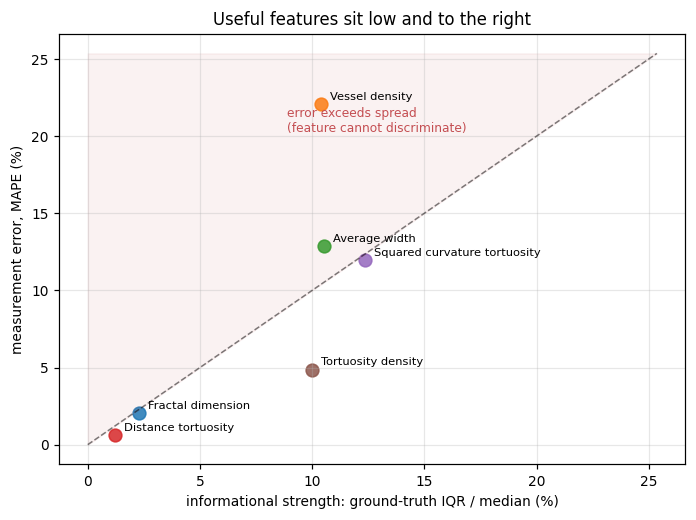

In [26]:
fig, ax = plt.subplots(figsize=(6.4, 4.8))

for feature in FEATURES:
    ax.scatter(combined.loc[feature, "gt_IQR_over_median"] * 100,
               agreement.loc[feature, "MAPE_%"], s=70, alpha=0.85)
    ax.annotate(feature.replace("_", " "),
                (combined.loc[feature, "gt_IQR_over_median"] * 100, agreement.loc[feature, "MAPE_%"]),
                fontsize=7.5, xytext=(6, 3), textcoords="offset points")

ceiling = max(combined["gt_IQR_over_median"].max() * 100, agreement["MAPE_%"].max()) * 1.15
ax.plot([0, ceiling], [0, ceiling], "k--", lw=1, alpha=0.5)
ax.fill_between([0, ceiling], [0, ceiling], ceiling, color="#C44E52", alpha=0.07)
ax.text(ceiling * 0.35, ceiling * 0.8, "error exceeds spread\n(feature cannot discriminate)",
        fontsize=8, color="#C44E52")

ax.set(xlabel="informational strength: ground-truth IQR / median (%)",
       ylabel="measurement error, MAPE (%)",
       title="Useful features sit low and to the right")
fig.tight_layout()

## 7. Verdict per feature

Generated from the numbers above rather than hand-written, so it cannot drift out of sync with the
data. The thresholds are judgement calls, stated explicitly in the code so they can be argued with.
A feature whose ICC depends on one image is judged on the leave-one-out value, not the headline.

In [27]:
def verdict(feature):
    icc = agreement.loc[feature, "ICC21"]
    if leverage.loc[feature, "fragile"]:
        icc = leverage.loc[feature, "ICC_without_it"]        # judge on the robust value
    if not np.isfinite(icc):
        # icc21 returns NaN for a feature that is constant across subjects: there is no
        # between-subject variance for an agreement coefficient to be a ratio of.
        return "unusable - constant across eyes, no agreement is definable"
    spearman = agreement.loc[feature, "spearman_r"]
    mape = agreement.loc[feature, "MAPE_%"]
    bias = abs(agreement.loc[feature, "rel_bias_%"])
    ratio = combined.loc[feature, "spread_to_noise"]

    if icc < 0.5 and spearman < 0.5:
        return "unusable - no agreement with truth"
    if ratio < 1.0:
        return "error covers the population spread - cannot rank eyes"
    if bias > 10:
        return "rank-usable, biased - calibrate before quoting absolutes"
    if mape < 5 and icc >= 0.75:
        return "reliable"
    return "usable with care"


verdicts = pd.DataFrame(
    {
        "rel_bias_%": agreement["rel_bias_%"],
        "MAE": agreement["MAE"],
        "MAPE_%": agreement["MAPE_%"],
        "pearson_r": agreement["pearson_r"],
        "spearman_r": agreement["spearman_r"],
        "ICC21": agreement["ICC21"],
        "ICC_robust": leverage["ICC_without_it"].where(leverage["fragile"], agreement["ICC21"]),
        "gt_IQR_over_median": combined["gt_IQR_over_median"],
        "spread_to_noise": combined["spread_to_noise"],
    }
)
verdicts["verdict"] = [verdict(feature) for feature in verdicts.index]
display(verdicts.round(3).sort_values("ICC_robust", ascending=False))

,rel_bias_%,MAE,MAPE_%,pearson_r,spearman_r,ICC21,ICC_robust,gt_IQR_over_median,spread_to_noise,verdict
feature,,,,,,,,,,
Distance_tortuosity,-0.473,0.007,0.631,0.693,0.849,0.618,0.818,0.012,1.153,reliable
Tortuosity_density,-2.019,0.031,4.856,0.827,0.720,0.813,0.813,0.100,1.756,reliable
Fractal_dimension,-2.007,0.030,2.024,0.926,0.869,0.701,0.701,0.023,1.645,usable with care
Vessel_density,-21.421,0.018,22.052,0.889,0.792,0.409,0.409,0.104,1.446,"rank-usable, biased - calibrate before quoting..."
Average_width,-12.943,14.932,12.886,0.766,0.832,0.319,0.319,0.105,1.966,"rank-usable, biased - calibrate before quoting..."
Squared_curvature_tortuosity,-4.670,0.016,11.943,0.252,0.250,0.236,0.236,0.123,0.824,unusable - no agreement with truth


## 8. Conclusions

Generated from the run below, so the prose cannot drift from the numbers.

In [28]:
lines = [f"RUN: {RUN_LABEL}", ""]

lines += [
    "SEGMENTATION",
    f"  Dice {ok['dice'].mean():.3f}, sensitivity {ok['sensitivity'].mean():.3f}, "
    f"specificity {ok['specificity'].mean():.3f} over n={len(ok)}.",
    f"  The model under-segments: it misses ~{100 * (1 - ok['sensitivity'].mean()):.0f}% of annotated"
    " vessel and invents almost none.",
    f"  Dice correlates with sensitivity at r={ok['dice'].corr(ok['sensitivity']):.3f}, so here Dice"
    " is largely a restatement of sensitivity.",
    "",
    "QUALITY GATE",
]

if GATE_ENFORCED:
    dropped = int((scores["status"] != "ok").sum())
    lines += [
        f"  Enforced. It rejected {dropped} of {len(scores)} FIVES quality-3 images; rejection is"
        " silent and total.",
        "  Feature results below are conditioned on the survivors, so they are optimistic.",
    ]
elif REJECTED_BY_M1:
    inside = ok[ok["key"].isin(REJECTED_BY_M1)]["dice"]
    outside = ok[~ok["key"].isin(REJECTED_BY_M1)]["dice"]
    _, p_gate = stats.mannwhitneyu(inside, outside)
    lines += [
        f"  Bypassed; all {len(ok)} images segmented.",
        f"  The {len(inside)} images M1 would have rejected score Dice {inside.mean():.3f} against"
        f" {outside.mean():.3f} for the rest (Mann-Whitney p={p_gate:.3f}).",
        f"  Discarding them would raise mean Dice by {outside.mean() - ok['dice'].mean():+.4f} while"
        f" losing {100 * len(inside) / len(ok):.0f}% of the cohort.",
    ]
else:
    lines += [f"  Bypassed; all {len(ok)} images segmented."]

lines += ["", "FEATURE AGREEMENT"]
for feature in verdicts.sort_values("ICC_robust", ascending=False).index:
    row = verdicts.loc[feature]
    note = "  (leverage-adjusted)" if leverage.loc[feature, "fragile"] else ""
    lines.append(
        f"  {feature:30s} ICC={row['ICC_robust']:5.2f} ({icc_label(row['ICC_robust']):9s})"
        f" bias={row['rel_bias_%']:+6.1f}%  MAPE={row['MAPE_%']:5.1f}%"
        f"  spread/noise={row['spread_to_noise']:4.1f}{note}"
    )
    lines.append(f"      -> {row['verdict']}")

proxy = proxy_table["corr(dice, |rel err|)"].sort_values()
lines += [
    "",
    "IS DICE A USABLE PROXY?",
    "  In production there are no annotations, so Dice is the only handle available.",
    f"  It tracks feature error well for: {', '.join(proxy[proxy < -0.5].index) or 'nothing'}",
    f"  It is uninformative about:       {', '.join(proxy[proxy > -0.3].index) or 'nothing'}",
]

print("\n".join(lines))

RUN: M0 + M2 vessel only, gate bypassed, tortuosity fix applied

SEGMENTATION
  Dice 0.825, sensitivity 0.736, specificity 0.995 over n=32.
  The model under-segments: it misses ~26% of annotated vessel and invents almost none.
  Dice correlates with sensitivity at r=0.987, so here Dice is largely a restatement of sensitivity.

QUALITY GATE
  Bypassed; all 32 images segmented.
  The 6 images M1 would have rejected score Dice 0.794 against 0.832 for the rest (Mann-Whitney p=0.025).
  Discarding them would raise mean Dice by +0.0072 while losing 19% of the cohort.

FEATURE AGREEMENT
  Distance_tortuosity            ICC= 0.82 (good     ) bias=  -0.5%  MAPE=  0.6%  spread/noise= 1.2  (leverage-adjusted)
      -> reliable
  Tortuosity_density             ICC= 0.81 (good     ) bias=  -2.0%  MAPE=  4.9%  spread/noise= 1.8
      -> reliable
  Fractal_dimension              ICC= 0.70 (moderate ) bias=  -2.0%  MAPE=  2.0%  spread/noise= 1.6
      -> usable with care
  Vessel_density             

In [29]:
# Save the tables next to the rest of this run's output.
agreement.round(6).to_csv(RESULTS / "feature_agreement.csv")
verdicts.round(6).to_csv(RESULTS / "feature_verdicts.csv")
strength.round(6).to_csv(RESULTS / "feature_informational_strength.csv")
leverage.to_csv(RESULTS / "feature_leverage.csv")
proxy_table.round(6).to_csv(RESULTS / "dice_as_proxy.csv")
Path(RESULTS / "conclusions.txt").write_text("\n".join(lines) + "\n")
print(f"wrote agreement, verdicts, informational strength, leverage, proxy and conclusions to {RESULTS}")

wrote agreement, verdicts, informational strength, leverage, proxy and conclusions to /Users/staskh/Sandbox/AutoMorph/benchmark/results/M2_vessels_fixed_mean
